The goal of the problem is to find the fraudulent transactions in the dataset.

Challenges:
1. Imabalanced dataset - When a dataset contains majority of one class and miority of another class, this creates imbalance. When a model is trained on this type of dataset, the model is baised means it is unable to detect the fraudlent transaction even it has 98% accuracy it failes to detect fraud transactions, we use Precision, Recall & F1 Score.

As we have to classify the transactions are normal or fraud, this is a classification problem and the metrics for classification are Accuracy, Precision, Recall & F1 Score.

2. Ensuring high precision to minimize False Positives

3. Ensuring high recall to detect as many fraud cases as possible.


# Steps in Machine Learning

1. Defining the problem - Identify the problem. As we have to detect fraud transactions, it is a Classification Problem.

2. Data Collection - Collect the data from different sources. Here we are using Credit Card Fraud Detection Dataset from Kaggle.

3. Data Preprocessing - Data cleaning and formatting and handling missing values and removing inconsistencies.

4. Feature Engineering - Select and transform the raw data into meaningful features that improves accuracy of the model.

5. Model Selection - Choose model based on the problem type. Here we are using Logistic Regression and Random Forest.

6. Model Training - Train the model on the training dataset

7. Model Evaluation - Access performance using metrics on a seperate testing set. As it is a classification problem, the metrics used are Accuracy, Precision, Recall and F1 Score.

8. Hyperparameter Tuning - Optimizing the model's settings to improve performance.

9. Deployement & Monitoring - Deploy the model and monitor it for accuracy.

# Load the dataset and perform basic Exploratory Data Analysis (EDA)
1. How many transactions are there?
2. How many are fraud vs normal?
3. Any missing values?

# 1. Importing necessary Libraries

Importing the necessary Python libraries: numpy, pandas, matplotlib and seaborn for data handling, visualization and model building.

In [ ]:
# Importing necessary libraries
import numpy as np # Import numpy, numpy for mathematical calculations
import pandas as pd # Importing pandas, pandas for creating dataframes
import matplotlib.pyplot as plt # Importing matplotlib, matplotlib for data visualizations
import seaborn as sns # Importing seaborn, seaborn for data visualizations

# 2. Loading the dataset

Load the dataset into a pandas DataFrame and examine its structure. The dataset contains 284,807 transactions with 31 features including:

| Column   | Description                                                                       |
| -------- | --------------------------------------------------------------------------------- |
| Time     | Seconds elapsed between this transaction and the first transaction in the dataset |
| V1 – V28 | Principal components obtained using **PCA (Principal Component Analysis)**        |
| Amount   | Transaction amount                                                                |
| Class    | Target variable (0 = Normal, 1 = Fraud)                                           |


For privacy reasons, the original features (like merchant name, location, etc.) were transformed using PCA. PCA (Principal Component Analysis) converts original sensitive features into new numerical components.

In [ ]:
# loading the dataset
data = pd.read_csv("/content/creditcard.csv") # Reading the csv file and converting it into dataframe and storing in the data
print(data.head()) # Printing the first 5 rows in the dataframe

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [ ]:
print(data.describe()) # Printing the data with metrics as mean, standard deviation and percentile

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [ ]:
# Basic EDA
# # Dataset shape
# How many transactions are there?
print("Dataset Shape:", data.shape)

Dataset Shape: (284807, 31)


In [ ]:
# Transaction counts
# How many are fraud vs normal?
print("\nFraud vs Normal:")
print(data['Class'].value_counts())


Fraud vs Normal:
Class
0    284315
1       492
Name: count, dtype: int64


In [ ]:
# Missing values
# Any missing values?
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


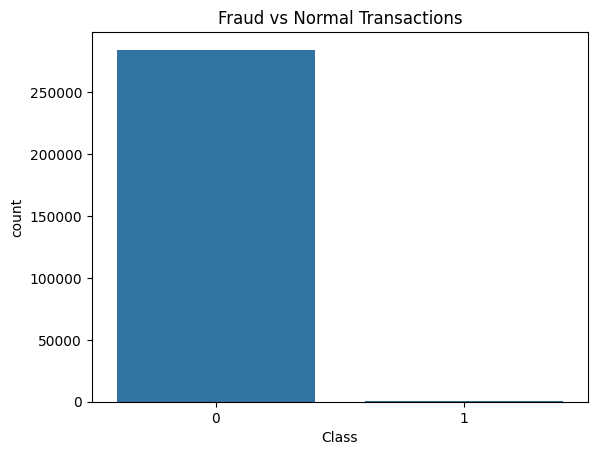

In [ ]:
# Fraud Distribution
sns.countplot(x="Class", data=data)
plt.title("Fraud vs Normal Transactions")
plt.show()

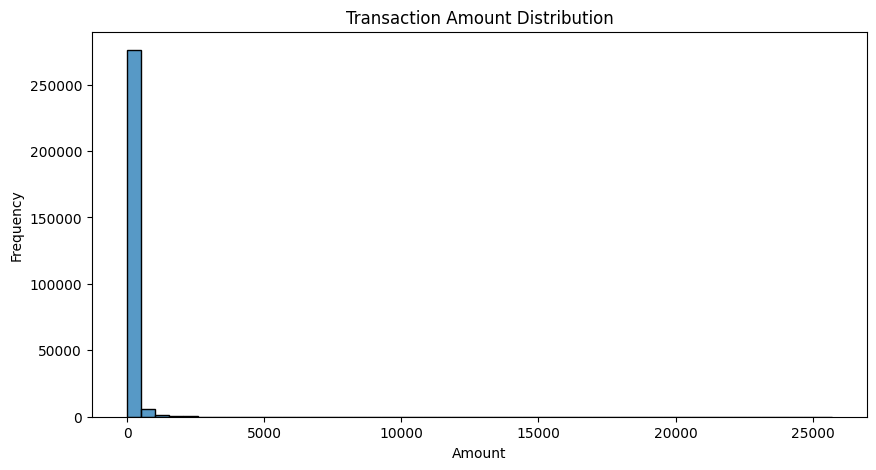

In [ ]:
# Transaction Amount Distribution
plt.figure(figsize=(10,5))

sns.histplot(data['Amount'], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

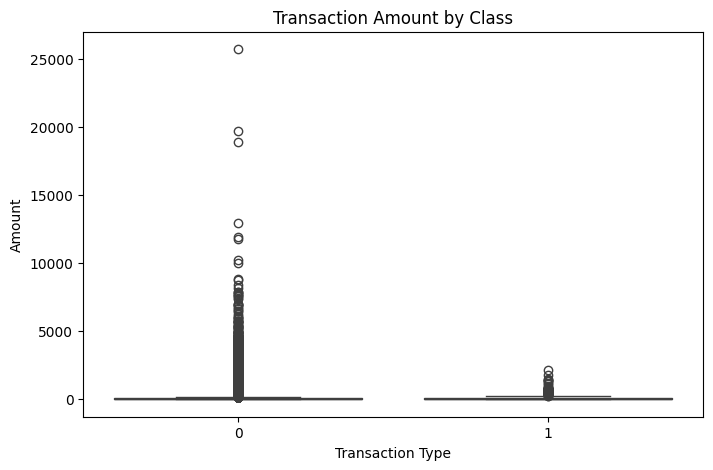

In [ ]:
# Fraud vs Normal Transaction Amount
plt.figure(figsize=(8,5))

sns.boxplot(x="Class", y="Amount", data=data)

plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Type")
plt.ylabel("Amount")

plt.show()

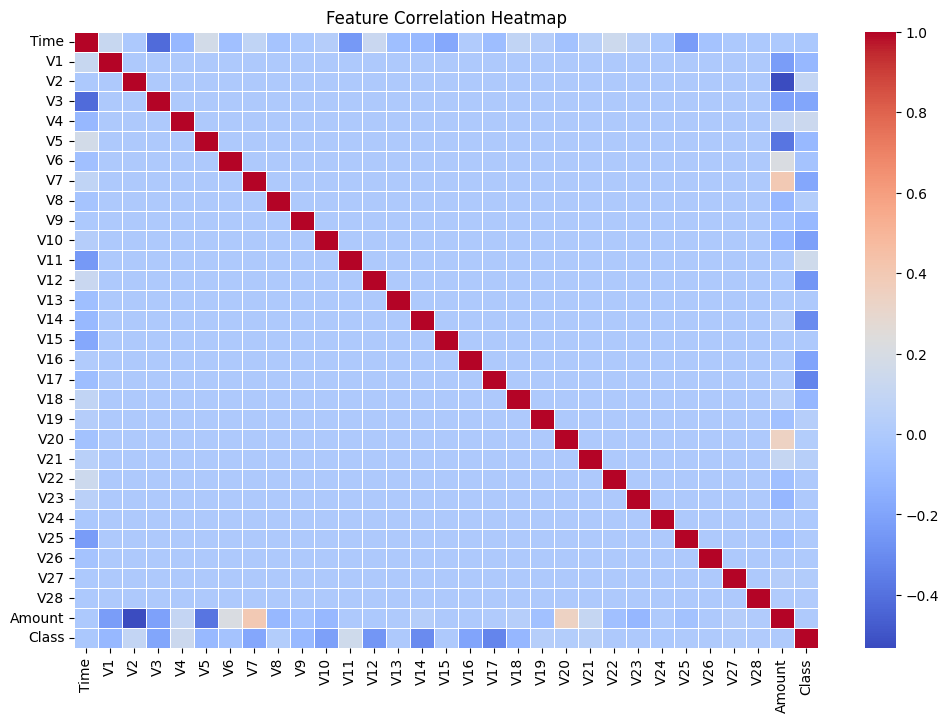

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

corr = data.corr()

sns.heatmap(corr, cmap="coolwarm", linewidths=0.5)

plt.title("Feature Correlation Heatmap")

plt.show()

In [ ]:
# Data Preprocessing
X = data.drop("Class", axis=1)
y = data["Class"]

In [ ]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [44]:
# Model 1 — Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight='balanced')

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [45]:
# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1 Score:", lr_f1)

Logistic Regression Results
Accuracy: 0.9754573224254767
Precision: 0.060810810810810814
Recall: 0.9183673469387755
F1 Score: 0.11406844106463879


In [46]:
# Model 2 — Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [47]:
# Metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)

Random Forest Results
Accuracy: 0.9995084442259752
Precision: 0.9605263157894737
Recall: 0.7448979591836735
F1 Score: 0.8390804597701149


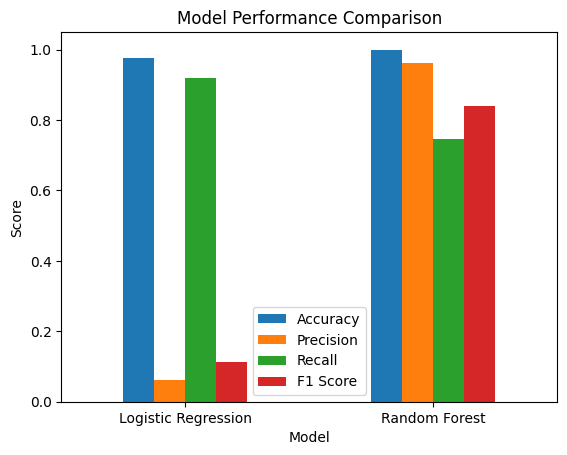

In [48]:
# Bar Chart for Model Metrics Comparison
import matplotlib.pyplot as plt
import pandas as pd

# Model results
results = {
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy],
    "Precision": [lr_precision, rf_precision],
    "Recall": [lr_recall, rf_recall],
    "F1 Score": [lr_f1, rf_f1]
}

results_df = pd.DataFrame(results)

results_df.set_index("Model").plot(kind="bar")

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

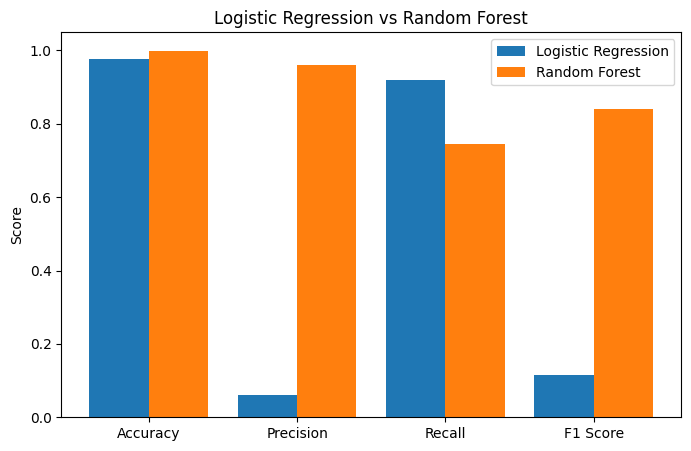

In [49]:
# Separate Metric Comparison Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

lr_scores = [lr_accuracy, lr_precision, lr_recall, lr_f1]
rf_scores = [rf_accuracy, rf_precision, rf_recall, rf_f1]

x = range(len(metrics))

plt.figure(figsize=(8,5))

plt.bar(x, lr_scores, width=0.4, label="Logistic Regression")
plt.bar([i + 0.4 for i in x], rf_scores, width=0.4, label="Random Forest")

plt.xticks([i + 0.2 for i in x], metrics)

plt.title("Logistic Regression vs Random Forest")
plt.ylabel("Score")
plt.legend()

plt.show()

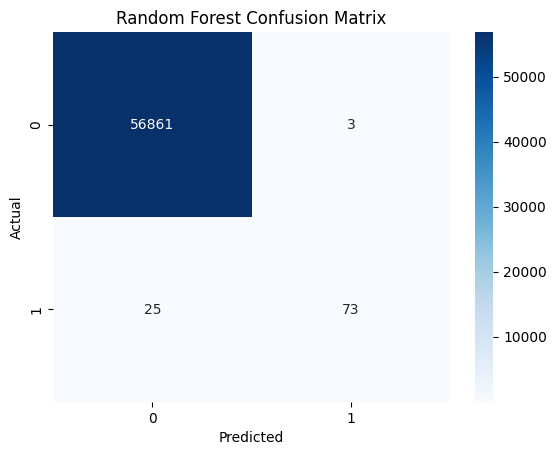

In [50]:
# Confusion Matrix Visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

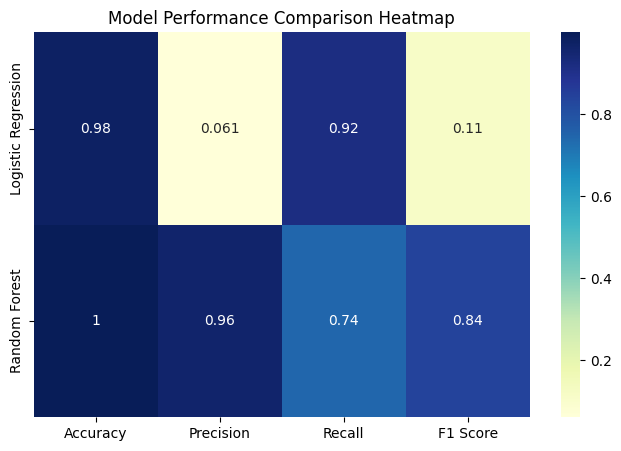

In [51]:
# Model Performance Heatmap
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Model performance data
performance = pd.DataFrame({
    "Accuracy": [lr_accuracy, rf_accuracy],
    "Precision": [lr_precision, rf_precision],
    "Recall": [lr_recall, rf_recall],
    "F1 Score": [lr_f1, rf_f1]
}, index=["Logistic Regression", "Random Forest"])

plt.figure(figsize=(8,5))

sns.heatmap(performance, annot=True, cmap="YlGnBu")

plt.title("Model Performance Comparison Heatmap")

plt.show()

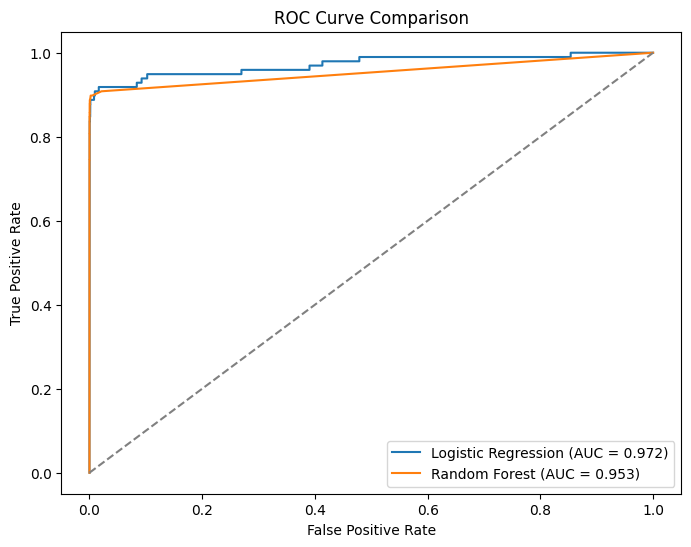

In [52]:
# ROC - AUC Curve
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression probabilities
lr_probs = lr.predict_proba(X_test)[:,1]

# Random Forest probabilities
rf_probs = rf.predict_proba(X_test)[:,1]

# ROC values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

# AUC scores
lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

# Plot ROC Curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [53]:
# Improvement
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Logitic Regression
- Accuracy (97.5%)
The model correctly classified most transactions. However, accuracy can be misleading in highly imbalanced datasets.

- Precision (6%)
Very low precision means that many transactions predicted as fraud are actually normal transactions (high false positives).

- Recall (91.8%)
Very high recall means the model successfully detects most fraud cases.

- F1 Score (0.11)
The F1 score is low because precision is extremely low, meaning the model is not reliable overall.

- Logistic Regression detects most fraud cases, but it flags too many normal transactions as fraud, which is not practical in real systems.

# Random Forest
- Accuracy (99.95%)
Very high accuracy indicates the model correctly classifies almost all transactions.

- Precision (96%)
High precision means when the model predicts fraud, it is usually correct.

- Recall (74%)
The model detects about 74% of fraud cases, which is still strong performance.

- F1 Score (0.839)
High F1 score shows a good balance between precision and recall.

- Random Forest is much more reliable because it balances fraud detection with fewer false alarms.

# Model Comparision
| Model               | Accuracy | Precision | Recall | F1 Score |
| ------------------- | -------- | --------- | ------ | -------- |
| Logistic Regression | 0.9755   | 0.0608    | 0.9184 | 0.1141   |
| Random Forest       | 0.9995   | 0.9605    | 0.7449 | 0.8391   |

- Random Forest achieved much higher precision and F1 score, meaning it is better at correctly identifying fraud transactions without producing many false alarms.

- Logistic Regression has very high recall, which means it catches most fraud cases but produces many false positives due to extremely low precision.

- For fraud detection systems, a balance between precision and recall is important, and Random Forest provides a better overall performance.

# Summary
This project builds a fraud detection system using the Credit Card Fraud Detection dataset. The dataset contains 284,807 transactions, with only 492 fraudulent cases, making it highly imbalanced. Two machine learning models, Logistic Regression and Random Forest, were trained and evaluated. Random Forest performed better with higher precision, recall, and F1 score, making it more effective at detecting fraudulent transactions. The most interesting insight was the extreme class imbalance, which makes fraud detection a challenging machine learning problem.

1. Which Model Performed Better?

    Random Forest

2. Why?

   Because it:
    - Captures non-linear patterns
    - Handles imbalanced data better
    - Detects more fraud cases (higher recall)

3. Interesting Finding

    The dataset is extremely imbalanced:

          Fraud = 0.17%

          Normal = 99.83%

This means a model can achieve 99% accuracy by predicting everything as normal, so Precision, Recall, and F1 score are more important than Accuracy.

# Conclusion
Random Forest performed better than Logistic Regression for fraud detection. While Logistic Regression achieved higher recall and detected more fraud cases, it produced many false positives due to very low precision. Random Forest achieved much higher precision and F1 score, providing a better balance between detecting fraud and avoiding false alerts. Therefore, Random Forest is a more reliable model for this fraud detection task.